# Economy, Energy Mix, and Responsibility in Global CO2 Emissions

I analyze why national CO2 emissions differ so sharply across countries. The main question is: **How do economic development, energy demand, fuel mix, and trade accounting shape national emissions responsibility?**

The argument is that wealth matters, but it is not enough. Richer countries usually emit more CO2 per person, yet emissions intensity depends on the structure of the energy system and the economy. Responsibility also changes when emissions are counted by consumption rather than only by where they are produced.

The analysis moves from data and methods to three linked hypotheses and a short synthesis.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('../data/raw/owid-co2-data.csv')
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

df = pd.read_csv(DATA)
countries = df[df['iso_code'].notna() & (df['iso_code'].str.len() == 3)].copy()

print('Rows, columns:', df.shape)
print('Years:', df['year'].min(), 'to', df['year'].max())
print('Countries/territories with ISO codes:', countries['country'].nunique())
countries.head()

Rows, columns: (50411, 79)
Years: 1750 to 2024
Countries/territories with ISO codes: 218


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data and Scope

The analysis uses the Our World in Data CO2 dataset. It includes country-year observations for emissions, population, GDP, energy use, fuel-specific emissions, consumption-based emissions, and trade-adjusted emissions.

Different indicators have different latest usable years, so I use the newest year with broad country coverage for each question:

- 2022 for GDP-heavy and energy-per-capita analysis.
- 2023 for consumption and trade-adjusted emissions.
- 2024 for fuel-mix and latest territorial emissions analysis.

Countries with very small populations are filtered out in the hypothesis tests to keep microstate outliers from driving the results. The analysis is observational, so it tests associations and structural patterns rather than proving a single policy caused a national emissions path.


In [2]:
coverage_specs = {
    'GDP + population + CO2': ['gdp', 'population', 'co2', 'co2_per_capita'],
    'Trade/consumption CO2': ['consumption_co2', 'trade_co2_share', 'co2'],
    'Energy intensity': ['energy_per_capita', 'co2_per_unit_energy'],
    'Fuel mix': ['coal_co2', 'oil_co2', 'gas_co2', 'co2'],
}

rows = []
for label, cols in coverage_specs.items():
    valid = countries.dropna(subset=cols)
    counts = valid.groupby('year').size()
    latest = counts[counts >= 80].index.max()
    rows.append({
        'section': label,
        'latest_year_with_80plus_countries': latest,
        'country_count': int(counts.loc[latest]),
    })

pd.DataFrame(rows)

,section,latest_year_with_80plus_countries,country_count
0,GDP + population + CO2,2022,164
1,Trade/consumption CO2,2023,120
2,Energy intensity,2023,203
3,Fuel mix,2024,110


In [3]:
def spearman_corr(x, y):
    return pd.Series(x).rank().corr(pd.Series(y).rank())


def permutation_corr_test(x, y, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.array(x, copy=True)
    y = np.array(y, copy=True)
    observed = spearman_corr(x, y)
    count = 0
    for _ in range(n):
        if abs(spearman_corr(x, rng.permutation(y))) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)


def permutation_mean_test(a, b, n=5000, seed=1):
    rng = np.random.default_rng(seed)
    a = np.array(a, copy=True)
    b = np.array(b, copy=True)
    observed = a.mean() - b.mean()
    pool = np.concatenate([a, b])
    n_a = len(a)
    count = 0
    for _ in range(n):
        permuted = rng.permutation(pool)
        diff = permuted[:n_a].mean() - permuted[n_a:].mean()
        if abs(diff) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)

## Methods

I use four statistical tools to check the main chart patterns:

- **Spearman correlation** tests whether two variables move together in rank order. This is more appropriate than relying only on linear correlation because country-level CO2 variables are skewed and contain outliers.
- **Permutation tests** estimate how surprising an observed relationship would be if labels or values were randomly rearranged under a null hypothesis.
- **Bootstrap confidence intervals** estimate uncertainty in the coal-intensity gap without assuming that country emissions follow a normal distribution.
- **K-means clustering** is used as exploratory pattern discovery. It groups countries by emissions profile, not as a causal model or moral ranking.

These checks come before the hypothesis sections because they explain how the results are evaluated.


In [4]:
# Construct the high-coal vs low-coal comparison used to validate H2A.
h2_methods = countries[countries['year'] == 2024].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2', 'co2', 'co2_per_unit_energy', 'population']
).copy()
h2_methods = h2_methods[(h2_methods['population'] >= 1_000_000) & (h2_methods['co2'] > 20)]
h2_methods['known_fossil_co2'] = h2_methods[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
h2_methods = h2_methods[h2_methods['known_fossil_co2'] > 0]
h2_methods['coal_share'] = h2_methods['coal_co2'] / h2_methods['known_fossil_co2']

high_coal = h2_methods[h2_methods['coal_share'] >= 0.5]['co2_per_unit_energy'].to_numpy()
low_coal = h2_methods[h2_methods['coal_share'] < 0.2]['co2_per_unit_energy'].to_numpy()
observed_gap = high_coal.mean() - low_coal.mean()

print(f'High-coal countries: n={len(high_coal)}, mean={high_coal.mean():.3f} kg CO2/kWh')
print(f'Low-coal countries: n={len(low_coal)}, mean={low_coal.mean():.3f} kg CO2/kWh')
print(f'Observed mean gap: {observed_gap:.3f} kg CO2/kWh')


High-coal countries: n=8, mean=0.274 kg CO2/kWh
Low-coal countries: n=39, mean=0.168 kg CO2/kWh
Observed mean gap: 0.106 kg CO2/kWh


### Permutation Test

The null hypothesis is that coal-heavy and low-coal labels are exchangeable. If coal share does not matter, randomly shuffling labels should often produce a gap as large as the observed gap. The p-value below is the fraction of shuffled-label simulations that produce an absolute mean gap at least as large as the real one.


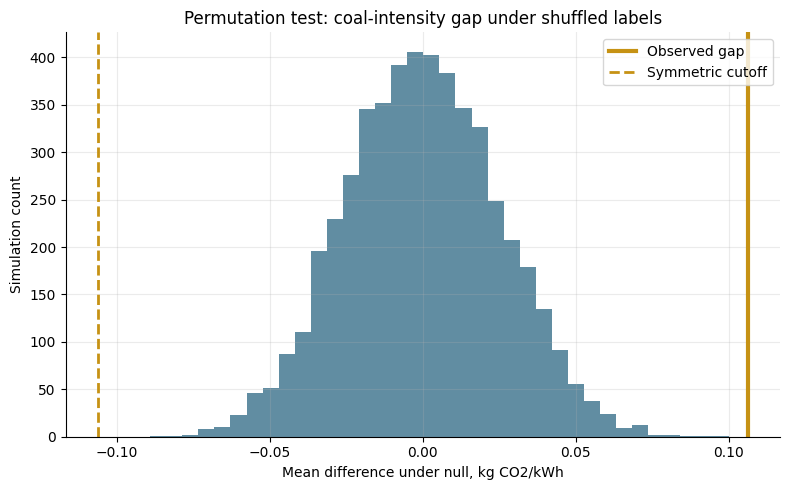

,observed_gap,permutation_p_value,simulations
0,0.106112,0.0002,5000


In [5]:
rng = np.random.default_rng(328)
pool = np.concatenate([high_coal, low_coal])
perm_diffs = []
for _ in range(5000):
    permuted = rng.permutation(pool)
    perm_diffs.append(permuted[:len(high_coal)].mean() - permuted[len(high_coal):].mean())
perm_diffs = np.array(perm_diffs)
perm_p = (np.sum(np.abs(perm_diffs) >= abs(observed_gap)) + 1) / (len(perm_diffs) + 1)

fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=36, color='#356d88', alpha=0.78)
ax.axvline(observed_gap, color='#c69214', linewidth=3, label='Observed gap')
ax.axvline(-observed_gap, color='#c69214', linewidth=2, linestyle='--', label='Symmetric cutoff')
ax.set_title('Permutation test: coal-intensity gap under shuffled labels')
ax.set_xlabel('Mean difference under null, kg CO2/kWh')
ax.set_ylabel('Simulation count')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'methods_permutation_test.png', dpi=180)
plt.show()

pd.DataFrame([{
    'observed_gap': observed_gap,
    'permutation_p_value': perm_p,
    'simulations': len(perm_diffs),
}])

### Bootstrap Confidence Interval

The bootstrap resamples high-coal and low-coal countries with replacement and recomputes the mean gap. This gives uncertainty bounds for the estimated coal-intensity difference without assuming a normal population distribution.


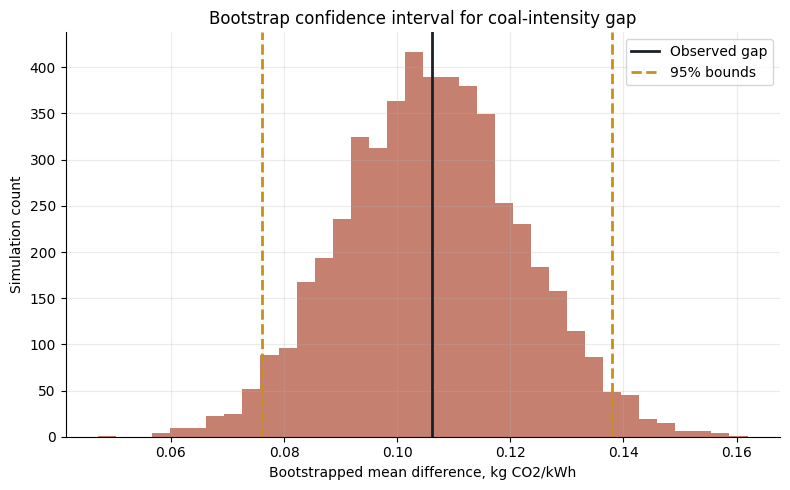

,observed_gap,ci_lower_2_5_pct,ci_upper_97_5_pct
0,0.106112,0.076114,0.137975


In [6]:
boot_diffs = []
for _ in range(5000):
    boot_high = rng.choice(high_coal, size=len(high_coal), replace=True)
    boot_low = rng.choice(low_coal, size=len(low_coal), replace=True)
    boot_diffs.append(boot_high.mean() - boot_low.mean())
boot_diffs = np.array(boot_diffs)
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

fig, ax = plt.subplots()
ax.hist(boot_diffs, bins=36, color='#b4553f', alpha=0.75)
ax.axvline(observed_gap, color='#192026', linewidth=2, label='Observed gap')
ax.axvline(ci_low, color='#c69214', linewidth=2, linestyle='--', label='95% bounds')
ax.axvline(ci_high, color='#c69214', linewidth=2, linestyle='--')
ax.set_title('Bootstrap confidence interval for coal-intensity gap')
ax.set_xlabel('Bootstrapped mean difference, kg CO2/kWh')
ax.set_ylabel('Simulation count')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'methods_bootstrap_bounds.png', dpi=180)
plt.show()

pd.DataFrame([{
    'observed_gap': observed_gap,
    'ci_lower_2_5_pct': ci_low,
    'ci_upper_97_5_pct': ci_high,
}])

### Central Limit Theorem Check

The distribution of country CO2 per capita is highly skewed, but repeated sample means are smoother and more concentrated around the population mean. This is a sanity check for why averages and confidence intervals can still be informative, while also reminding us that outliers must be handled carefully.


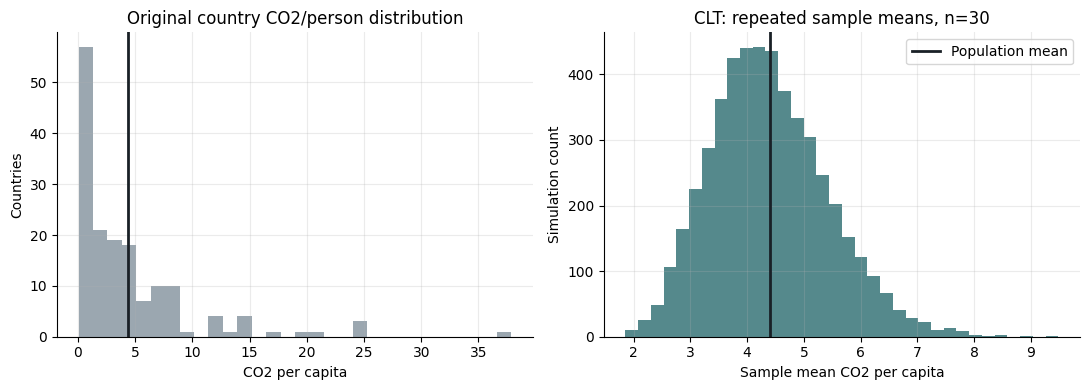

,population_mean,mean_of_sample_means,standard_error_simulated,sample_size
0,4.395421,4.390085,1.030855,30


In [7]:
co2pc_2022 = countries[(countries['year'] == 2022) & (countries['population'] >= 1_000_000)]['co2_per_capita'].dropna().to_numpy()
sample_size = 30
sample_means = np.array([
    rng.choice(co2pc_2022, size=sample_size, replace=True).mean()
    for _ in range(5000)
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(co2pc_2022, bins=30, color='#8a98a3', alpha=0.85)
axes[0].axvline(co2pc_2022.mean(), color='#192026', linewidth=2)
axes[0].set_title('Original country CO2/person distribution')
axes[0].set_xlabel('CO2 per capita')
axes[0].set_ylabel('Countries')

axes[1].hist(sample_means, bins=34, color='#2f6f73', alpha=0.82)
axes[1].axvline(co2pc_2022.mean(), color='#192026', linewidth=2, label='Population mean')
axes[1].set_title('CLT: repeated sample means, n=30')
axes[1].set_xlabel('Sample mean CO2 per capita')
axes[1].set_ylabel('Simulation count')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES / 'methods_clt_sample_means.png', dpi=180)
plt.show()

pd.DataFrame([{
    'population_mean': co2pc_2022.mean(),
    'mean_of_sample_means': sample_means.mean(),
    'standard_error_simulated': sample_means.std(ddof=1),
    'sample_size': sample_size,
}])

### K-means Clustering

K-means groups countries using standardized 2022 values of log GDP per capita, log energy per capita, CO2 per capita, and CO2 per GDP. The clusters are not moral categories and not causal proof; they are a compact way to show that countries occupy different emissions profiles.


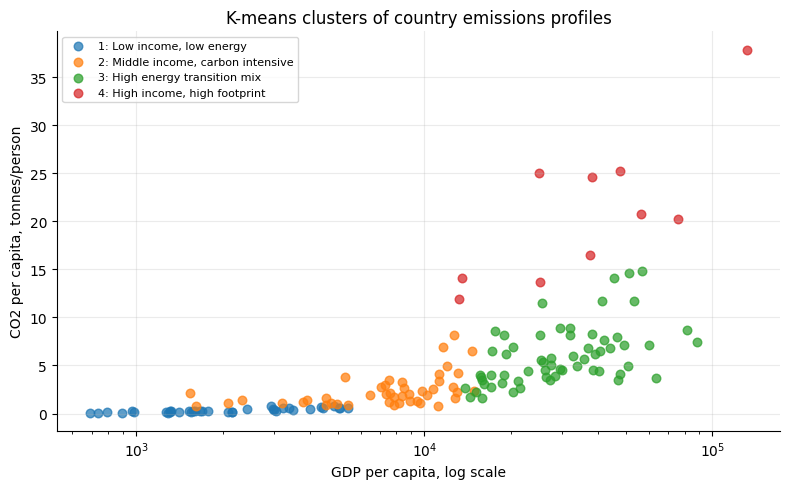

,cluster,cluster_name,countries,avg_gdp_per_capita,avg_energy_per_capita,avg_co2_per_capita,avg_co2_per_gdp
0,1,"Low income, low energy",37,2391.717823,1407.265270,0.332324,0.142027
1,2,"Middle income, carbon intensive",45,8138.788014,9828.472444,2.375756,0.326333
2,3,High energy transition mix,61,32741.217076,36964.033393,6.024754,0.200000
3,4,"High income, high footprint",10,46526.597719,101628.519500,21.005600,0.602600


In [8]:
cluster_df = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'energy_per_capita', 'co2_per_capita', 'co2_per_gdp']
).copy()
cluster_df = cluster_df[cluster_df['population'] >= 1_000_000]
cluster_df['gdp_per_capita'] = cluster_df['gdp'] / cluster_df['population']

features = np.column_stack([
    np.log10(cluster_df['gdp_per_capita']),
    np.log10(cluster_df['energy_per_capita']),
    cluster_df['co2_per_capita'],
    cluster_df['co2_per_gdp'],
])
z = (features - features.mean(axis=0)) / features.std(axis=0)

k = 4
order = np.argsort(z[:, 0])
centroids = z[order[np.linspace(0, len(order) - 1, k, dtype=int)]].copy()
labels = np.zeros(len(z), dtype=int)
for _ in range(100):
    distances = ((z[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    new_labels = distances.argmin(axis=1)
    if np.array_equal(labels, new_labels):
        break
    labels = new_labels
    for group in range(k):
        if np.any(labels == group):
            centroids[group] = z[labels == group].mean(axis=0)

cluster_df['cluster_raw'] = labels
ranked = cluster_df.groupby('cluster_raw')['gdp_per_capita'].mean().sort_values().index.tolist()
cluster_df['cluster'] = cluster_df['cluster_raw'].map({raw: idx for idx, raw in enumerate(ranked, start=1)})
cluster_names = {
    1: 'Low income, low energy',
    2: 'Middle income, carbon intensive',
    3: 'High energy transition mix',
    4: 'High income, high footprint',
}
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)

fig, ax = plt.subplots()
for cluster_id, group in cluster_df.groupby('cluster'):
    ax.scatter(
        group['gdp_per_capita'],
        group['co2_per_capita'],
        s=38,
        alpha=0.72,
        label=f'{cluster_id}: {cluster_names[cluster_id]}',
    )
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('K-means clusters of country emissions profiles')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'methods_kmeans_clusters.png', dpi=180)
plt.show()

cluster_summary = cluster_df.groupby(['cluster', 'cluster_name']).agg(
    countries=('country', 'count'),
    avg_gdp_per_capita=('gdp_per_capita', 'mean'),
    avg_energy_per_capita=('energy_per_capita', 'mean'),
    avg_co2_per_capita=('co2_per_capita', 'mean'),
    avg_co2_per_gdp=('co2_per_gdp', 'mean'),
).reset_index()
cluster_summary

### Methods Takeaway

The statistical checks support the main results. The coal-intensity gap is unlikely under random label shuffling, the bootstrap interval stays above zero, the CLT check explains why sample means are useful despite skew, and k-means shows that countries fall into distinct emissions profiles rather than a simple rich/poor binary.


## Results and Interpretation

The three hypotheses below build from direct national emissions patterns to broader questions of responsibility. Hypothesis 1 tests whether wealth explains emissions, Hypothesis 2 tests the role of energy demand and fuel mix, and Hypothesis 3 compares territorial responsibility with consumption responsibility over time.


## Hypothesis 1: Economy

**H1A:** Higher GDP per capita is associated with higher CO2 per capita.

**H1B:** GDP per capita alone does not reliably predict CO2 per GDP; energy mix and economic structure explain variation better.


In [9]:
h1 = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'co2_per_capita', 'co2_per_gdp']
).copy()
h1 = h1[h1['population'] >= 1_000_000]
h1['gdp_per_capita'] = h1['gdp'] / h1['population']

stats_rows = []
for x, y, label in [
    ('gdp_per_capita', 'co2_per_capita', 'GDP per capita vs CO2 per capita'),
    ('gdp_per_capita', 'co2_per_gdp', 'GDP per capita vs CO2 per GDP'),
]:
    d = h1[[x, y]].dropna()
    r, p = permutation_corr_test(d[x], d[y], n=1000)
    stats_rows.append({'comparison': label, 'spearman_r': round(r, 3), 'permutation_p': round(p, 4), 'n': len(d)})

pd.DataFrame(stats_rows)

,comparison,spearman_r,permutation_p,n
0,GDP per capita vs CO2 per capita,0.891,0.0010,153
1,GDP per capita vs CO2 per GDP,0.083,0.3007,153


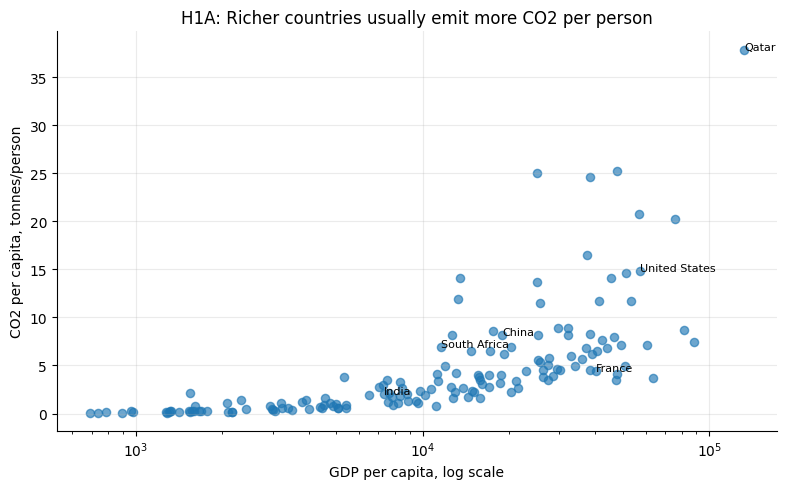

In [10]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_capita'], alpha=0.65, s=35)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H1A: Richer countries usually emit more CO2 per person')

for name in ['United States', 'China', 'India', 'Qatar', 'France', 'South Africa']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1a_gdp_vs_co2_per_capita.png', dpi=180)
plt.show()

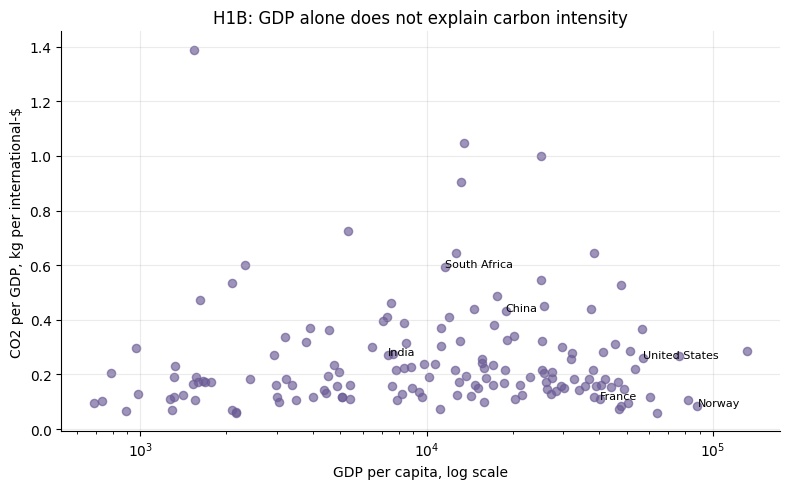

In [11]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_gdp'], alpha=0.65, s=35, color='#6b5b95')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per GDP, kg per international-$')
ax.set_title('H1B: GDP alone does not explain carbon intensity')

for name in ['China', 'India', 'South Africa', 'United States', 'France', 'Norway']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_gdp'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1b_gdp_vs_co2_per_gdp.png', dpi=180)
plt.show()

### Interpretation: Economy

The economy section shows that wealth is strongly associated with emissions per person, but it is not a complete explanation of emissions intensity. Using 2022, the latest year with broad GDP coverage, countries with population above one million show a strong positive relationship between GDP per capita and CO2 per capita: the Spearman correlation is about 0.891. This supports H1A. Richer countries usually have larger homes, more transport, more electricity demand, and more energy-intensive consumption, so their average resident tends to be responsible for more CO2.

H1B is more interesting because the relationship nearly disappears when emissions are divided by GDP. GDP per capita and CO2 per GDP have a weak Spearman correlation of only about 0.083. This means rich countries are not automatically more carbon-intensive per dollar of output. Some relatively wealthy countries have lower CO2 per GDP because their economies are more service-oriented or their electricity systems are cleaner, while some middle-income or fossil-fuel-dependent countries produce much more CO2 for each unit of economic output. The outliers matter: countries such as Turkmenistan, Trinidad and Tobago, Mongolia, Bahrain, and North Korea rank high on CO2 per GDP for very different reasons.

The conclusion is that economic development increases per-person emissions, but GDP alone does not determine how dirty an economy is. Per-capita emissions measure individual footprint; CO2 per GDP measures production efficiency. Both are needed for a fair comparison.


## Hypothesis 2: Energy Mix

**H2A:** Coal-heavy countries have higher CO2 emissions intensity.

**H2B:** Energy use per capita strongly predicts CO2 per capita, but cleaner energy mixes create exceptions.


In [12]:
h2 = countries[countries['year'] == 2024].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2', 'co2', 'co2_per_unit_energy', 'population']
).copy()
h2 = h2[(h2['population'] >= 1_000_000) & (h2['co2'] > 20)]
h2['known_fossil_co2'] = h2[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
h2 = h2[h2['known_fossil_co2'] > 0]
h2['coal_share'] = h2['coal_co2'] / h2['known_fossil_co2']

high_coal = h2[h2['coal_share'] >= 0.5]['co2_per_unit_energy'].dropna()
low_coal = h2[h2['coal_share'] < 0.2]['co2_per_unit_energy'].dropna()
diff, p = permutation_mean_test(high_coal, low_coal, n=2000)

pd.DataFrame([
    {'group': 'coal share >= 50%', 'n': len(high_coal), 'mean_co2_per_unit_energy': high_coal.mean()},
    {'group': 'coal share < 20%', 'n': len(low_coal), 'mean_co2_per_unit_energy': low_coal.mean()},
    {'group': 'difference and p-value', 'n': '', 'mean_co2_per_unit_energy': f'diff={diff:.3f}, p={p:.4f}'},
])

,group,n,mean_co2_per_unit_energy
0,coal share >= 50%,8,0.273625
1,coal share < 20%,39,0.167513
2,difference and p-value,,"diff=0.106, p=0.0005"


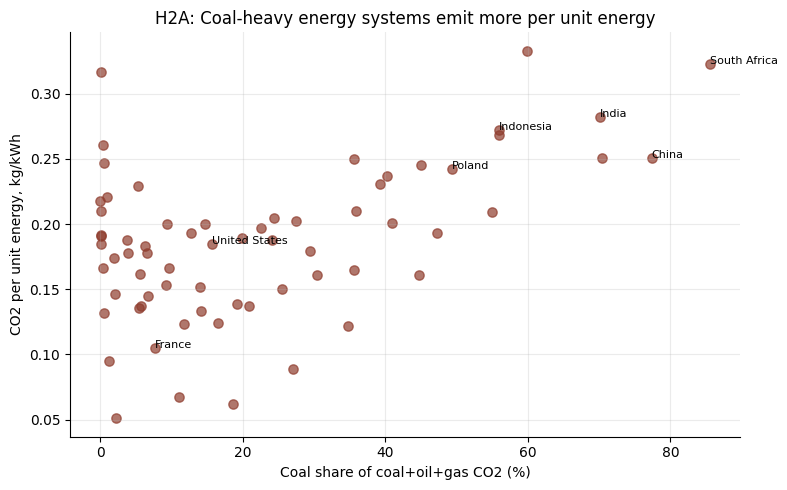

In [13]:
fig, ax = plt.subplots()
ax.scatter(h2['coal_share'] * 100, h2['co2_per_unit_energy'], alpha=0.7, s=45, color='#8f3d2e')
ax.set_xlabel('Coal share of coal+oil+gas CO2 (%)')
ax.set_ylabel('CO2 per unit energy, kg/kWh')
ax.set_title('H2A: Coal-heavy energy systems emit more per unit energy')

for name in ['South Africa', 'China', 'India', 'Indonesia', 'Poland', 'United States', 'France']:
    row = h2[h2['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['coal_share'].iloc[0] * 100, row['co2_per_unit_energy'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2a_coal_share_vs_energy_intensity.png', dpi=180)
plt.show()

Spearman r = 0.970, permutation p = 0.0010, n = 159


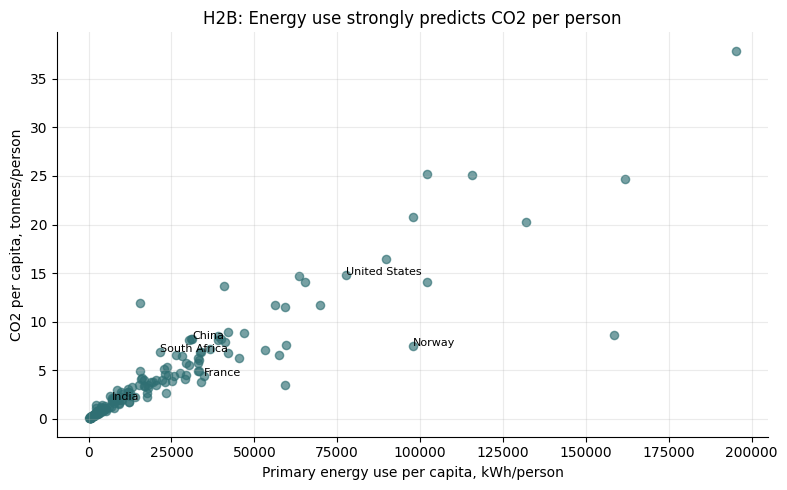

In [14]:
h2b = countries[countries['year'] == 2022].dropna(
    subset=['energy_per_capita', 'co2_per_capita', 'population']
).copy()
h2b = h2b[h2b['population'] >= 1_000_000]

r, p = permutation_corr_test(h2b['energy_per_capita'], h2b['co2_per_capita'], n=1000)
print(f'Spearman r = {r:.3f}, permutation p = {p:.4f}, n = {len(h2b)}')

fig, ax = plt.subplots()
ax.scatter(h2b['energy_per_capita'], h2b['co2_per_capita'], alpha=0.65, s=35, color='#2f6f73')
ax.set_xlabel('Primary energy use per capita, kWh/person')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H2B: Energy use strongly predicts CO2 per person')

for name in ['United States', 'China', 'India', 'Norway', 'France', 'South Africa']:
    row = h2b[h2b['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['energy_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2b_energy_vs_co2_per_capita.png', dpi=180)
plt.show()

### Interpretation: Energy Mix

The energy-mix section explains why countries with similar levels of development can have very different emissions profiles. H2A is supported by the 2024 fuel data. Among countries with population above one million and more than 20 million tonnes of annual CO2, countries where coal makes up at least half of coal+oil+gas emissions average about 0.274 kg CO2 per kWh of primary energy. Countries where coal contributes less than 20% average about 0.168 kg CO2 per kWh. The gap is large: about 0.106 kg CO2 per kWh. This is visible in the coal-share scatterplot, where South Africa, China, India, Vietnam, Kazakhstan, Indonesia, and the Philippines sit high on coal dependence and energy carbon intensity.

H2B is also strongly supported. In 2022, energy use per capita and CO2 per capita have a Spearman correlation of about 0.970. That means the simplest predictor of a country's per-person CO2 emissions is how much energy each person uses. However, the plot also shows why energy quantity is not the whole story. Countries with high energy use can have lower emissions if their electricity and industry rely more on nuclear, hydro, renewables, or lower-carbon fuels. France and Norway are useful examples to compare with coal-heavy economies.

The main lesson is that climate outcomes depend on both demand and supply. A country can reduce emissions by lowering energy waste, but the bigger structural issue is often the fuel mix behind each unit of energy.


## Hypothesis 3: Trade, Responsibility, and Structural Change

**H3A:** Production-based and consumption-based emissions change which countries look responsible.

**H3B:** Some countries show declining emissions over time, which is consistent with policy, technology, and structural economic change, although the dataset alone cannot prove the exact cause.


In [15]:
h3 = countries[countries['year'] == 2023].dropna(
    subset=['co2', 'consumption_co2', 'trade_co2_share', 'population']
).copy()
h3 = h3[(h3['population'] >= 1_000_000) & (h3['co2'] > 5)]

h3[['country', 'co2', 'consumption_co2', 'trade_co2_share']].sort_values(
    'trade_co2_share', ascending=False
).head(10)

,country,co2,consumption_co2,trade_co2_share
21118,Hong Kong,32.957,144.164,337.429
44294,Switzerland,31.977,118.330,270.040
41363,Singapore,51.068,186.926,266.036
31960,Nepal,18.348,47.279,157.683
43582,Sri Lanka,19.166,46.439,142.300
5438,Belgium,84.703,196.605,132.110
25603,Latvia,6.590,13.362,102.763
7036,Botswana,7.249,14.509,100.160
8461,Cambodia,21.412,39.064,82.444
10981,Costa Rica,8.473,14.692,73.405


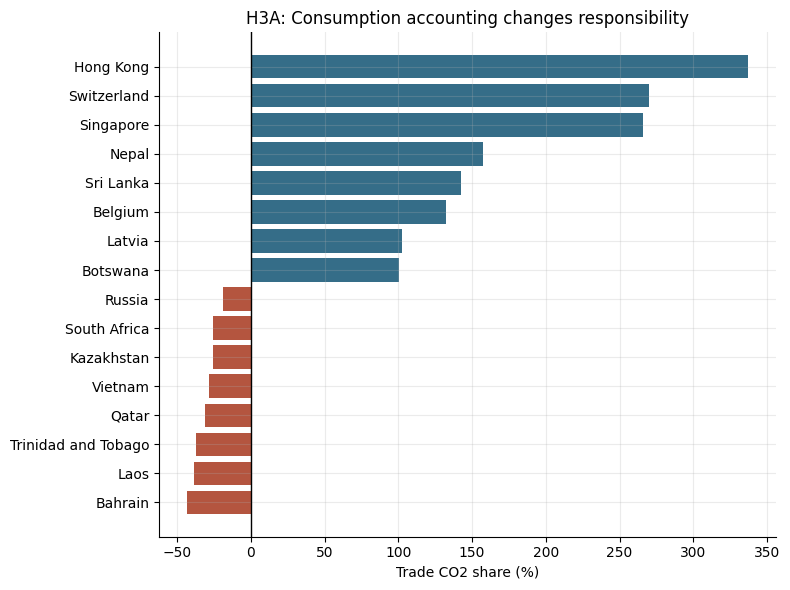

In [16]:
importers = h3.sort_values('trade_co2_share', ascending=False).head(8)
exporters = h3.sort_values('trade_co2_share', ascending=True).head(8)
trade_plot = pd.concat([exporters, importers]).sort_values('trade_co2_share')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#b4553f' if v < 0 else '#356d88' for v in trade_plot['trade_co2_share']]
ax.barh(trade_plot['country'], trade_plot['trade_co2_share'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Trade CO2 share (%)')
ax.set_title('H3A: Consumption accounting changes responsibility')
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_trade_co2_share.png', dpi=180)
plt.show()

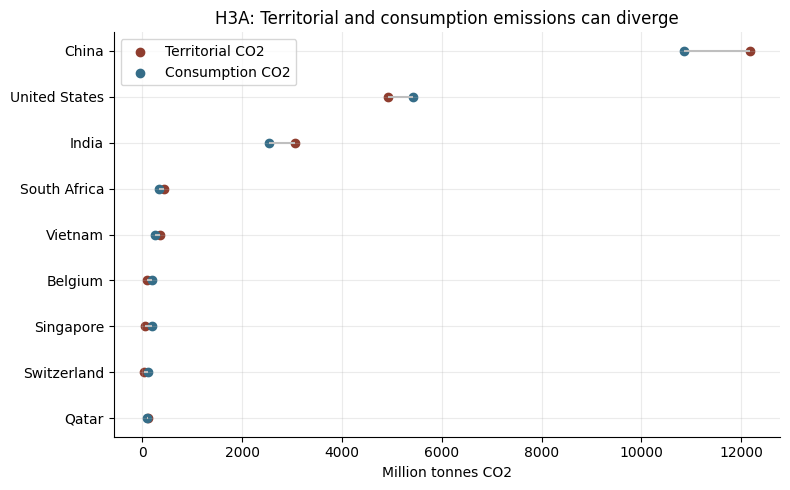

In [17]:
selected = ['Switzerland', 'Singapore', 'Belgium', 'United States', 'China', 'India', 'Vietnam', 'South Africa', 'Qatar']
pairs = h3[h3['country'].isin(selected)].sort_values('consumption_co2')

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(pairs))
ax.hlines(y, pairs['co2'], pairs['consumption_co2'], color='0.75')
ax.scatter(pairs['co2'], y, label='Territorial CO2', color='#8f3d2e')
ax.scatter(pairs['consumption_co2'], y, label='Consumption CO2', color='#356d88')
ax.set_yticks(y)
ax.set_yticklabels(pairs['country'])
ax.set_xlabel('Million tonnes CO2')
ax.set_title('H3A: Territorial and consumption emissions can diverge')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_territorial_vs_consumption.png', dpi=180)
plt.show()

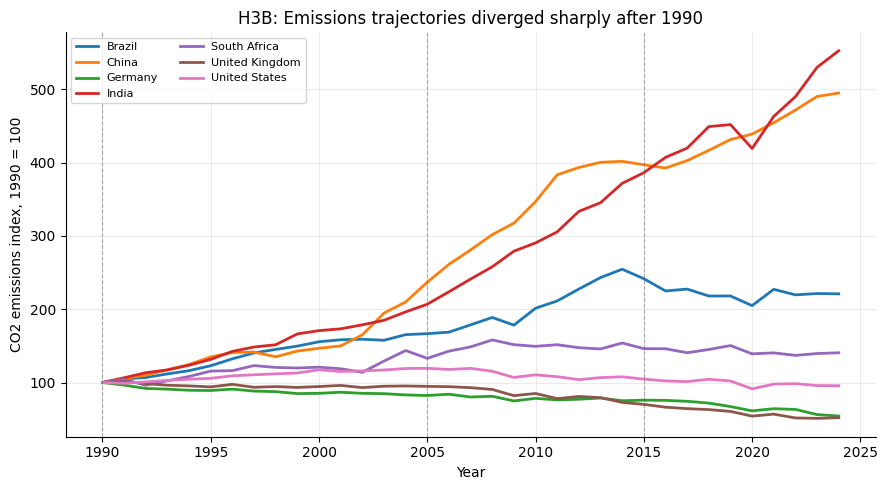

In [18]:
trend_countries = ['United States', 'China', 'India', 'Germany', 'United Kingdom', 'Brazil', 'South Africa']
base_year = 1990
trend = countries[countries['country'].isin(trend_countries) & (countries['year'] >= base_year)].copy()
trend = trend.dropna(subset=['co2'])
base = trend[trend['year'] == base_year][['country', 'co2']].rename(columns={'co2': 'base_co2'})
trend = trend.merge(base, on='country', how='inner')
trend['co2_index_1990_100'] = 100 * trend['co2'] / trend['base_co2']

fig, ax = plt.subplots(figsize=(9, 5))
for country, g in trend.groupby('country'):
    ax.plot(g['year'], g['co2_index_1990_100'], label=country, linewidth=2)
for year in [1990, 2005, 2015]:
    ax.axvline(year, color='0.4', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('CO2 emissions index, 1990 = 100')
ax.set_xlabel('Year')
ax.set_title('H3B: Emissions trajectories diverged sharply after 1990')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'h3b_trend_co2_index_1990.png', dpi=180)
plt.show()

### Interpretation: Trade, Responsibility, and Structural Change

The policy and trade section shows that responsibility changes when emissions are counted by consumption instead of production. H3A is supported by the 2023 consumption-based data. Countries such as Switzerland, Singapore, Hong Kong, and Belgium have consumption emissions far above their territorial emissions, meaning a large part of their carbon footprint is embedded in imported goods and services. Switzerland's trade-adjusted share is about +270%, Singapore's is about +266%, and Belgium's is about +132%. In contrast, Bahrain, Qatar, Vietnam, Kazakhstan, South Africa, Russia, and India have negative trade adjustments, meaning they produce more emissions domestically than their residents consume directly.

This matters because territorial accounting can make importer economies look cleaner than they are, while making exporter or manufacturing economies look dirtier. A fair climate discussion should therefore include both numbers: production emissions show where CO2 physically enters the atmosphere, while consumption emissions show who ultimately benefits from the goods being produced.

H3B is supported more cautiously. The indexed trend graph shows that some countries have reduced annual CO2 emissions since 1990, while others have grown sharply. By 2024, the United Kingdom and Germany are near 52% and 54% of their 1990 emissions, respectively. The United States is slightly below its 1990 level, while China and India are roughly five times higher. These declines are consistent with policy, technology shifts, deindustrialization, and cleaner energy, but this dataset alone cannot prove the exact cause. The correct claim is structural change, not simple policy causality.


## Conclusion

National CO2 emissions are not explained by wealth alone. Economic development is associated with higher per-person emissions, but the final emissions outcome depends on how much energy people use, whether that energy comes from coal-heavy systems, whether emissions are counted where goods are produced or consumed, and whether countries have managed to bend their emissions trend downward over time.

A fair interpretation combines all three lenses. Economic capacity helps explain who can consume more energy, fuel mix explains how carbon-intensive that energy is, and trade accounting shows who benefits from emissions that may occur somewhere else.
